# Analisi di `transactions_simple_calendar_pred.csv`

Dataset sintetico generato dall'esperimento **`simple_calendar`**: i clienti appartengono a quattro cluster (`calendar_phase_0`, `calendar_phase_2`, `calendar_phase_4`, `calendar_phase_6`) che condividono **lo stesso profilo di spesa, le stesse variabili categoriche, gli stessi volumi e la stessa distribuzione di `delta_t`**.

L'unico segnale discriminante introdotto dal generatore e' la **fase calendariale assoluta**: ogni cluster transa settimanalmente, ma su un diverso giorno della settimana. Il modello corrente non riceve `timestamp` come feature (`DEFAULT_FEATURES` resta `importo`, `merchant`, `cocau`) e usa il tempo solo via `delta_t`, quindi questo dataset e' un controllo negativo: con le feature del modello i cluster non dovrebbero separarsi.

Obiettivi del notebook:
1. verificare che `importo`, `merchant` e `cocau` siano sovrapposti tra cluster;
2. verificare che `delta_t` sia sostanzialmente identico tra cluster;
3. mostrare che la separazione compare solo usando feature calendariali derivate da `timestamp`;
4. confrontare proiezioni 2D per cliente con feature model-visible vs feature calendar-oracle.


In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 80)


In [14]:
def find_repo_root(start: Path) -> Path:
    """Risale le cartelle finche trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start


ROOT = find_repo_root(Path.cwd())
CSV = ROOT / 'data' / 'transactions_simple_calendar_pred.csv'

CLIENT, CLUSTER, TS = 'client_id', 'cluster', 'timestamp'
AMOUNT, MERCHANT, COCAU = 'importo', 'merchant', 'cocau'

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit='s')
df = df.sort_values([CLIENT, TS]).reset_index(drop=True)
df['delta_t_days'] = df.groupby(CLIENT)[TS].diff().dt.total_seconds() / 86400.0
df['hour'] = df[TS].dt.hour
df['dayofweek'] = df[TS].dt.dayofweek
df['day_name'] = df[TS].dt.day_name()

def cluster_phase(name: str) -> int:
    return int(name.rsplit('_', 1)[-1])


clusters = sorted(df[CLUSTER].unique(), key=cluster_phase)
palette = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']
colors_map = dict(zip(clusters, palette))

print('File:', CSV)
print('Righe x colonne:', df.shape)
df.head()


File: /workspaces/be-bper-ai-toolchain-bseq-app/data/transactions_simple_calendar_pred.csv
Righe x colonne: (54465, 10)


,client_id,cluster,timestamp,importo,merchant,cocau,delta_t_days,hour,dayofweek,day_name
0,0,calendar_phase_2,2020-01-03 15:22:33,108.673345,RyanAir,185,NaN,15,4,Friday
1,0,calendar_phase_2,2020-01-10 07:47:51,42.345712,IKEA,120,6.684236,7,4,Friday
2,0,calendar_phase_2,2020-01-17 14:38:02,117.627816,Mediaworld,120,7.284850,14,4,Friday
3,0,calendar_phase_2,2020-01-24 05:51:38,68.949197,Satispay,101,6.634444,5,4,Friday
4,0,calendar_phase_2,2020-01-31 02:43:18,70.880815,Coop,101,6.869213,2,4,Friday


## 0. Panoramica e qualita dei dati


In [15]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=True),
})
display(overview)

df.describe(include='all').transpose().head(12)


,dtype,missing,n_unique
client_id,int64,0,400
cluster,object,0,4
timestamp,datetime64[ns],0,54453
importo,float64,0,54465
merchant,object,0,26
cocau,int64,0,26
delta_t_days,float64,400,44354
hour,int32,0,24
dayofweek,int32,0,4
day_name,object,0,4


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
client_id,54465.0,NaN,NaN,NaN,196.296319,0.0,97.0,193.0,297.0,399.0,116.409353
cluster,54465,4,calendar_phase_4,14153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,54465,NaN,NaN,NaN,2021-12-27 08:24:31.583255552,2020-01-01 00:26:48,2021-02-28 01:57:12,2021-12-26 05:23:15,2022-10-26 12:09:37,2023-12-26 23:05:32,NaN
importo,54465.0,NaN,NaN,NaN,80.487938,-72.848455,40.571637,70.257044,110.465262,342.051217,55.953652
merchant,54465,26,Lidl,2201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cocau,54465.0,NaN,NaN,NaN,114.464922,8.0,101.0,120.0,120.0,296.0,50.668529
delta_t_days,54065.0,NaN,NaN,NaN,7.000341,6.008819,6.708507,7.001863,7.291921,7.991771,0.409397
hour,54465.0,NaN,NaN,NaN,11.429762,0.0,5.0,11.0,17.0,23.0,6.920728
dayofweek,54465.0,NaN,NaN,NaN,3.300358,1.0,2.0,4.0,6.0,6.0,1.930801
day_name,54465,4,Sunday,14153,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Bilanciamento dei cluster

Numero di clienti e di transazioni per cluster. Il generatore assegna lo stesso numero di clienti a ogni fase calendariale.


,n_clients,n_transactions,tx_per_client
cluster,,,
calendar_phase_0,100,13073,130.7
calendar_phase_2,100,13817,138.2
calendar_phase_4,100,14153,141.5
calendar_phase_6,100,13422,134.2


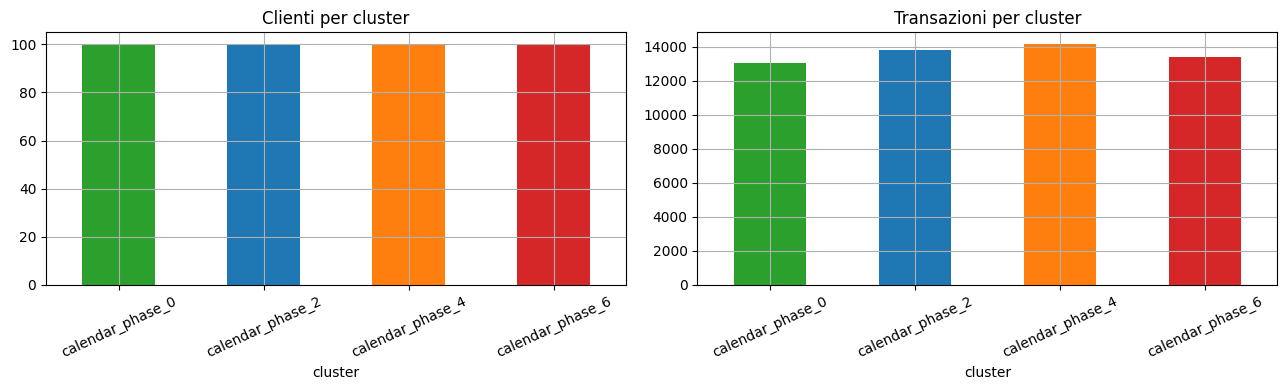

In [16]:
n_clients = df.groupby(CLUSTER)[CLIENT].nunique().reindex(clusters)
n_tx = df[CLUSTER].value_counts().reindex(clusters)
summary = pd.DataFrame({'n_clients': n_clients, 'n_transactions': n_tx})
summary['tx_per_client'] = (summary['n_transactions'] / summary['n_clients']).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.plot.bar(ax=ax[0], color=[colors_map[c] for c in clusters], title='Clienti per cluster')
n_tx.plot.bar(ax=ax[1], color=[colors_map[c] for c in clusters], title='Transazioni per cluster')
for a in ax:
    a.tick_params(axis='x', rotation=25)
plt.tight_layout()


## 2. Distribuzione di `importo`

In `simple_calendar` non ci aspettiamo separazione su `importo`: tutti i cluster condividono lo stesso profilo di spesa.


,mean,median,std
cluster,,,
calendar_phase_0,79.89,69.73,55.81
calendar_phase_2,80.50,70.67,55.93
calendar_phase_4,80.27,69.85,55.93
calendar_phase_6,81.29,70.80,56.14


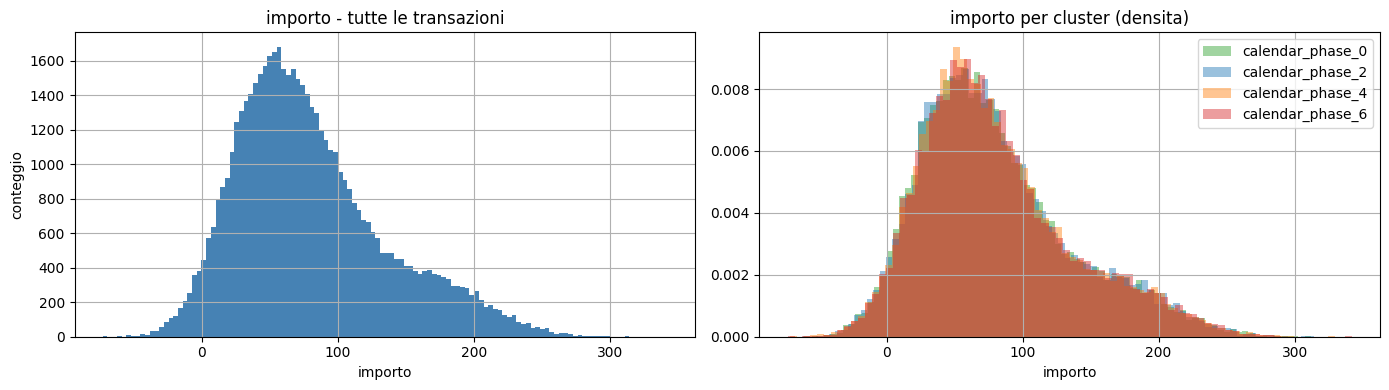

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df[AMOUNT], bins=120, color='steelblue')
ax[0].set(title='importo - tutte le transazioni', xlabel='importo', ylabel='conteggio')

for c in clusters:
    ax[1].hist(
        df.loc[df[CLUSTER] == c, AMOUNT],
        bins=80,
        alpha=0.45,
        density=True,
        label=c,
        color=colors_map[c],
    )
ax[1].set(title='importo per cluster (densita)', xlabel='importo')
ax[1].legend()
plt.tight_layout()

df.groupby(CLUSTER)[AMOUNT].agg(['mean', 'median', 'std']).reindex(clusters).round(2)


## 3. Variabili categoriche: `merchant` e `cocau`

Anche le variabili categoriche sono condivise. Se emergono pattern forti qui, il dataset non sarebbe un controllo calendar-only pulito.


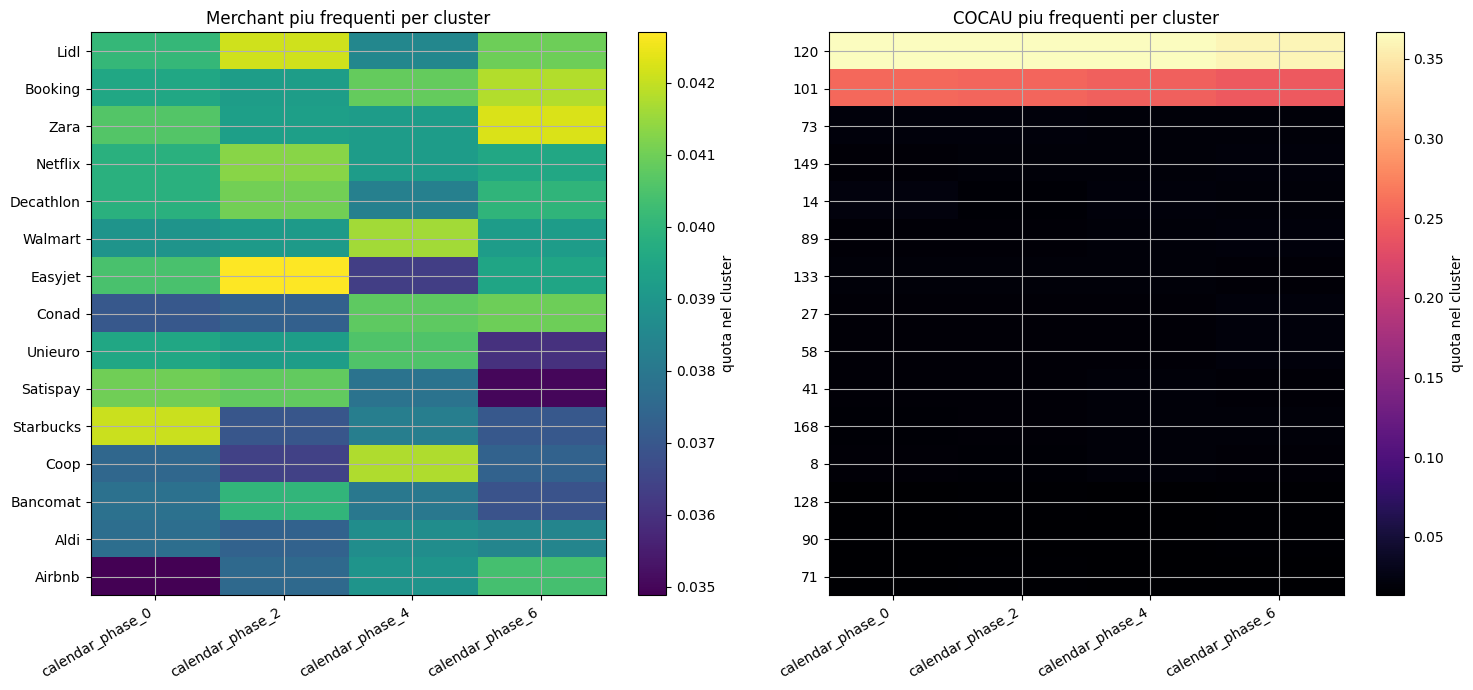

In [18]:
merchant_ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize='columns')
top_merchants = df[MERCHANT].value_counts().head(15).index
merchant_ct = merchant_ct.reindex(index=top_merchants, columns=clusters)

cocau_top = df[COCAU].value_counts().head(15).index
cocau_ct = pd.crosstab(df[COCAU], df[CLUSTER], normalize='columns')
cocau_ct = cocau_ct.reindex(index=cocau_top, columns=clusters)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
im0 = ax[0].imshow(merchant_ct.values, aspect='auto', cmap='viridis')
ax[0].set_xticks(range(len(merchant_ct.columns)))
ax[0].set_xticklabels(merchant_ct.columns, rotation=30, ha='right')
ax[0].set_yticks(range(len(merchant_ct.index)))
ax[0].set_yticklabels(merchant_ct.index)
ax[0].set_title('Merchant piu frequenti per cluster')
fig.colorbar(im0, ax=ax[0], label='quota nel cluster')

im1 = ax[1].imshow(cocau_ct.values, aspect='auto', cmap='magma')
ax[1].set_xticks(range(len(cocau_ct.columns)))
ax[1].set_xticklabels(cocau_ct.columns, rotation=30, ha='right')
ax[1].set_yticks(range(len(cocau_ct.index)))
ax[1].set_yticklabels(cocau_ct.index)
ax[1].set_title('COCAU piu frequenti per cluster')
fig.colorbar(im1, ax=ax[1], label='quota nel cluster')

plt.tight_layout()


## 4. Variabili temporali

Qui deve comparire la differenza importante: **`delta_t` resta uguale**, mentre il giorno assoluto della settimana cambia per cluster.


,mean,median,std,expected_mean_days,mean_error_days
cluster,,,,,
calendar_phase_0,7.001,7.004,0.411,7.0,0.001
calendar_phase_2,7.000,7.003,0.408,7.0,0.000
calendar_phase_4,7.000,6.999,0.410,7.0,0.000
calendar_phase_6,7.000,7.003,0.410,7.0,0.000


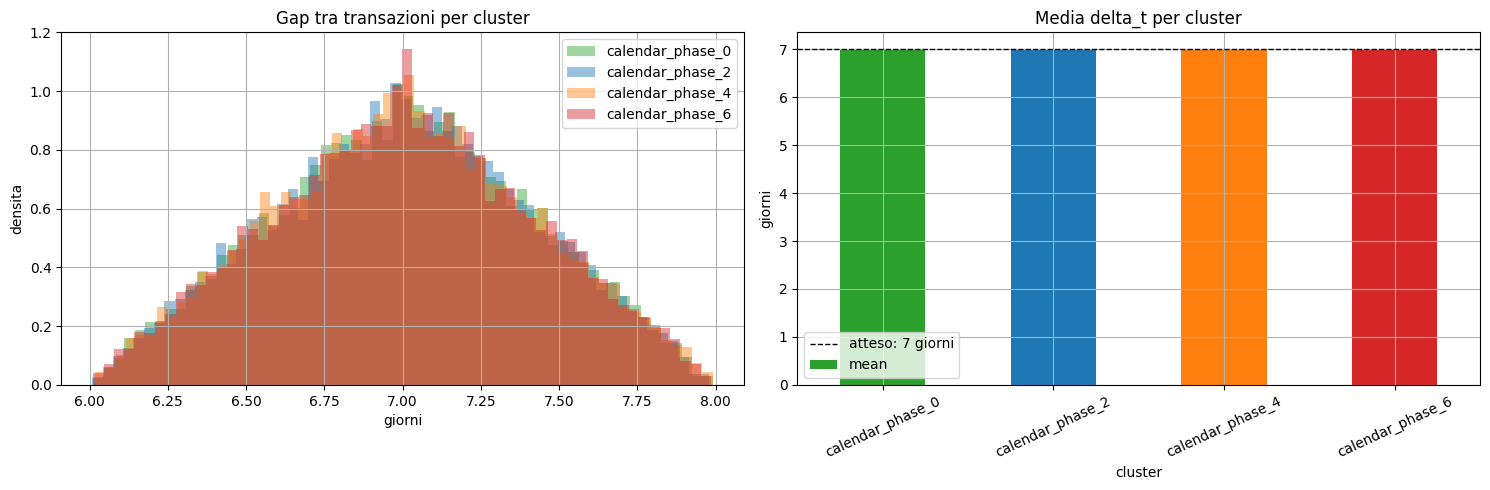

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for c in clusters:
    gap = df.loc[df[CLUSTER] == c, 'delta_t_days'].dropna()
    ax[0].hist(gap, bins=60, alpha=0.45, density=True, label=c, color=colors_map[c])
ax[0].set(title='Gap tra transazioni per cluster', xlabel='giorni', ylabel='densita')
ax[0].legend()

gap_stats = df.groupby(CLUSTER)['delta_t_days'].agg(['mean', 'median', 'std']).reindex(clusters)
gap_stats['expected_mean_days'] = 7.0
gap_stats['mean_error_days'] = gap_stats['mean'] - gap_stats['expected_mean_days']
gap_stats['mean'].plot.bar(ax=ax[1], color=[colors_map[c] for c in clusters], title='Media delta_t per cluster')
ax[1].axhline(7.0, color='black', linestyle='--', linewidth=1, label='atteso: 7 giorni')
ax[1].set_ylabel('giorni')
ax[1].tick_params(axis='x', rotation=25)
ax[1].legend()
plt.tight_layout()

gap_stats.round(3)


,mode_dayofweek,mode_day_name,weekday_share_at_mode
cluster,,,
calendar_phase_0,2,Wednesday,1.0
calendar_phase_2,4,Friday,1.0
calendar_phase_4,6,Sunday,1.0
calendar_phase_6,1,Tuesday,1.0


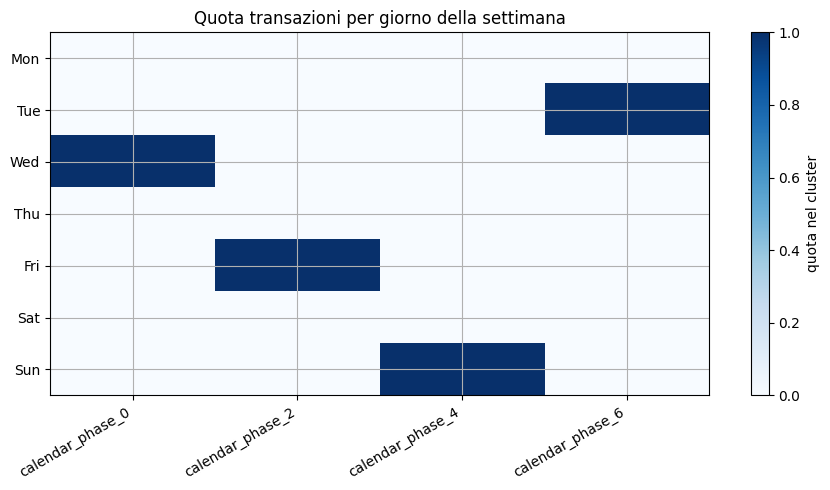

In [20]:
dow_ct = pd.crosstab(df['dayofweek'], df[CLUSTER], normalize='columns').reindex(index=range(7), columns=clusters, fill_value=0)
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(dow_ct.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(clusters)))
ax.set_xticklabels(clusters, rotation=30, ha='right')
ax.set_yticks(range(7))
ax.set_yticklabels(dow_labels)
ax.set_title('Quota transazioni per giorno della settimana')
fig.colorbar(im, ax=ax, label='quota nel cluster')
plt.tight_layout()

calendar_stats = pd.DataFrame({
    'mode_dayofweek': df.groupby(CLUSTER)['dayofweek'].agg(lambda s: int(s.mode().iloc[0])),
    'mode_day_name': df.groupby(CLUSTER)['day_name'].agg(lambda s: s.mode().iloc[0]),
    'weekday_share_at_mode': df.groupby(CLUSTER)['dayofweek'].agg(lambda s: s.value_counts(normalize=True).iloc[0]),
}).reindex(clusters)
calendar_stats


## 5. Transazioni per cliente

Il volume per cliente e' condiviso a livello di generatore: eventuali differenze dovrebbero essere contenute e non sistematiche.


,mean,median,std
cluster,,,
calendar_phase_0,130.73,146.5,66.84
calendar_phase_2,138.17,148.0,64.18
calendar_phase_4,141.53,152.0,64.63
calendar_phase_6,134.22,150.5,69.49


count    400.000000
mean     136.162500
std       66.195966
min        1.000000
25%       81.000000
50%      149.000000
75%      207.250000
max      208.000000
dtype: float64

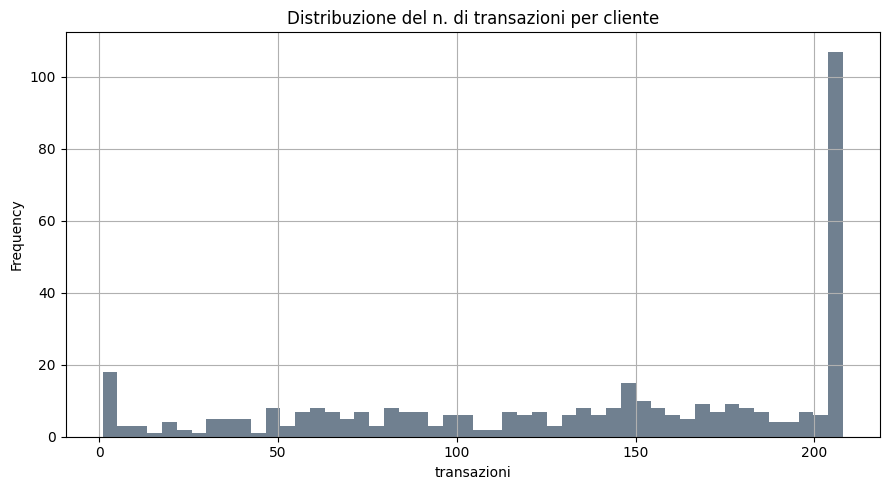

In [21]:
tx_per_client = df.groupby(CLIENT).size()
ax = tx_per_client.plot.hist(bins=50, title='Distribuzione del n. di transazioni per cliente', color='slategray')
ax.set_xlabel('transazioni')
plt.tight_layout()

tx_by_cluster = df.groupby([CLUSTER, CLIENT]).size().groupby(CLUSTER).agg(['mean', 'median', 'std']).reindex(clusters)
display(tx_by_cluster.round(2))
tx_per_client.describe()


## 6. Feature aggregate per cliente

Costruiamo due matrici:

1. **model-visible proxy**: importi, categoriche aggregate, volumi e statistiche di `delta_t`. Non contiene tempo assoluto.
2. **calendar-oracle**: aggiunge quote per giorno della settimana derivate da `timestamp`. Questa matrice contiene il segnale che il modello corrente non vede.


In [22]:
df_feat = df.assign(cocau_str=df[COCAU].astype(str))

base = df_feat.groupby(CLIENT).agg(
    amount_mean=(AMOUNT, 'mean'),
    amount_std=(AMOUNT, 'std'),
    amount_median=(AMOUNT, 'median'),
    amount_abs_mean=(AMOUNT, lambda s: s.abs().mean()),
    debt_share=(AMOUNT, lambda s: (s < 0).mean()),
    gap_mean_days=('delta_t_days', 'mean'),
    gap_median_days=('delta_t_days', 'median'),
    gap_std_days=('delta_t_days', 'std'),
    gap_p90_days=('delta_t_days', lambda s: s.quantile(0.9)),
    n_tx=(CLIENT, 'size'),
    n_merchant=(MERCHANT, 'nunique'),
    n_cocau=('cocau_str', 'nunique'),
)

merchant_share = pd.crosstab(df_feat[CLIENT], df_feat[MERCHANT], normalize='index')
merchant_share = merchant_share.reindex(columns=top_merchants, fill_value=0)
merchant_share.columns = [f'merchant__{c}' for c in merchant_share.columns]

top_cocau_str = df_feat['cocau_str'].value_counts().head(15).index
cocau_share = pd.crosstab(df_feat[CLIENT], df_feat['cocau_str'], normalize='index')
cocau_share = cocau_share.reindex(columns=top_cocau_str, fill_value=0)
cocau_share.columns = [f'cocau__{c}' for c in cocau_share.columns]

dow_share = pd.crosstab(df_feat[CLIENT], df_feat['dayofweek'], normalize='index')
dow_share = dow_share.reindex(columns=range(7), fill_value=0)
dow_share.columns = [f'dow__{dow_labels[i]}' for i in dow_share.columns]

visible_feats = base.join(merchant_share).join(cocau_share).fillna(0.0)
oracle_feats = visible_feats.join(dow_share).fillna(0.0)
labels = df.groupby(CLIENT)[CLUSTER].first().reindex(visible_feats.index)

print('visible_feats:', visible_feats.shape)
print('oracle_feats:', oracle_feats.shape)
visible_feats.head()


visible_feats: (400, 42)
oracle_feats: (400, 49)


,amount_mean,amount_std,amount_median,amount_abs_mean,debt_share,gap_mean_days,gap_median_days,gap_std_days,gap_p90_days,n_tx,n_merchant,n_cocau,merchant__Lidl,merchant__Booking,merchant__Zara,merchant__Netflix,merchant__Decathlon,merchant__Walmart,merchant__Easyjet,merchant__Conad,merchant__Unieuro,merchant__Satispay,merchant__Starbucks,merchant__Coop,merchant__Bancomat,merchant__Aldi,merchant__Airbnb,cocau__120,cocau__101,cocau__73,cocau__149,cocau__14,cocau__89,cocau__133,cocau__27,cocau__58,cocau__41,cocau__168,cocau__8,cocau__128,cocau__90,cocau__71
client_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,76.611369,53.775799,69.742037,77.906195,0.038462,6.997254,6.982477,0.420068,7.593058,208,26,25,0.043269,0.043269,0.043269,0.028846,0.024038,0.024038,0.052885,0.033654,0.057692,0.067308,0.033654,0.038462,0.043269,0.024038,0.014423,0.355769,0.278846,0.024038,0.014423,0.028846,0.038462,0.019231,0.009615,0.024038,0.014423,0.004808,0.014423,0.014423,0.009615,0.000000
1,84.043616,52.002361,72.975283,84.317455,0.015385,7.003990,7.029769,0.443265,7.583157,130,26,25,0.023077,0.069231,0.015385,0.007692,0.030769,0.053846,0.030769,0.030769,0.061538,0.061538,0.053846,0.023077,0.038462,0.030769,0.046154,0.323077,0.269231,0.007692,0.015385,0.023077,0.015385,0.015385,0.007692,0.015385,0.030769,0.030769,0.015385,0.007692,0.030769,0.038462
2,79.974290,44.543080,76.348034,80.084234,0.028986,7.004335,7.011476,0.360444,7.446334,69,24,15,0.028986,0.043478,0.000000,0.057971,0.028986,0.057971,0.043478,0.057971,0.028986,0.028986,0.028986,0.014493,0.043478,0.072464,0.000000,0.434783,0.246377,0.028986,0.043478,0.014493,0.014493,0.043478,0.000000,0.000000,0.000000,0.014493,0.043478,0.000000,0.000000,0.014493
3,83.246384,59.407078,71.903793,84.382013,0.029070,7.004020,6.997060,0.427300,7.611736,172,26,25,0.034884,0.046512,0.040698,0.046512,0.034884,0.040698,0.052326,0.029070,0.029070,0.034884,0.029070,0.040698,0.023256,0.023256,0.023256,0.348837,0.244186,0.029070,0.029070,0.029070,0.017442,0.005814,0.000000,0.029070,0.017442,0.005814,0.034884,0.011628,0.029070,0.029070
4,78.643244,57.822530,65.290438,79.732575,0.039409,7.001210,6.966563,0.392453,7.548231,203,26,26,0.034483,0.024631,0.039409,0.049261,0.044335,0.049261,0.034483,0.049261,0.049261,0.019704,0.049261,0.044335,0.034483,0.029557,0.064039,0.344828,0.231527,0.009852,0.024631,0.039409,0.014778,0.024631,0.034483,0.009852,0.019704,0.014778,0.029557,0.009852,0.029557,0.014778


,PC1,PC2
amount_median,-0.151,0.406
amount_mean,-0.095,0.448
amount_abs_mean,-0.089,0.449
amount_std,0.306,0.081
n_merchant,0.301,0.080
cocau__128,-0.088,0.276
gap_std_days,0.314,0.047
gap_p90_days,0.330,0.025
n_cocau,0.264,0.090
gap_mean_days,0.329,0.022


,PC1,PC2
amount_median,-0.152,0.406
amount_mean,-0.095,0.448
amount_abs_mean,-0.090,0.449
amount_std,0.305,0.082
n_merchant,0.301,0.080
cocau__128,-0.087,0.275
gap_std_days,0.314,0.048
gap_p90_days,0.330,0.026
n_cocau,0.263,0.090
gap_mean_days,0.328,0.023


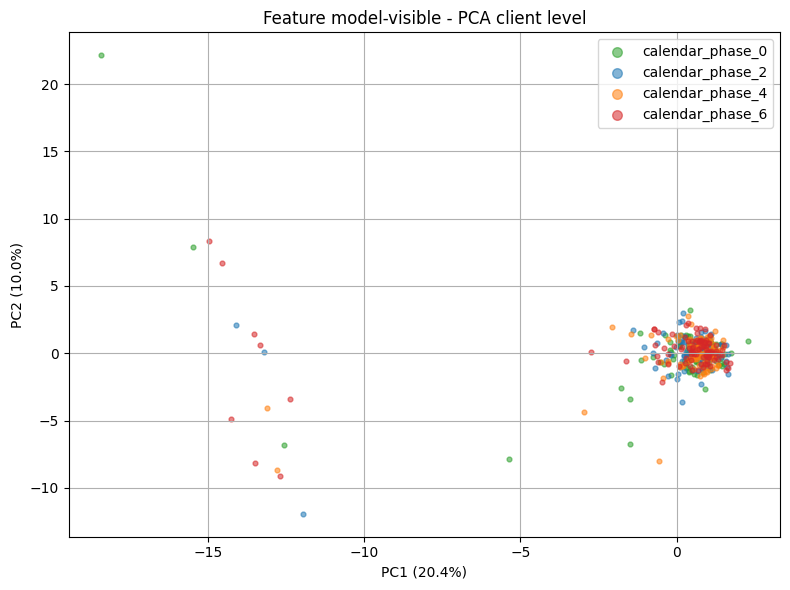

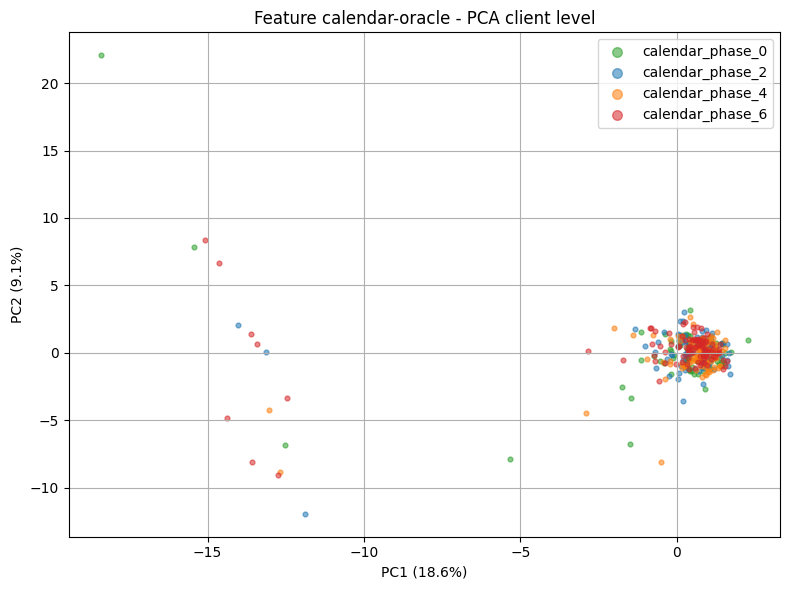

In [23]:
def pca_projection(feats: pd.DataFrame, title: str):
    X = StandardScaler().fit_transform(feats)
    pca = PCA(n_components=2, random_state=0)
    Xp = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 6))
    for c in clusters:
        mask = labels.values == c
        ax.scatter(Xp[mask, 0], Xp[mask, 1], s=12, alpha=0.55, label=c, color=colors_map[c])
    ax.set(
        title=f'{title} - PCA client level',
        xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
    )
    ax.legend(markerscale=2)
    plt.tight_layout()

    loadings = pd.DataFrame(pca.components_[:2].T, index=feats.columns, columns=['PC1', 'PC2'])
    order = loadings['PC1'].abs().add(loadings['PC2'].abs()).sort_values(ascending=False).index
    return loadings.loc[order].head(15).round(3)


display(pca_projection(visible_feats, 'Feature model-visible'))
display(pca_projection(oracle_feats, 'Feature calendar-oracle'))


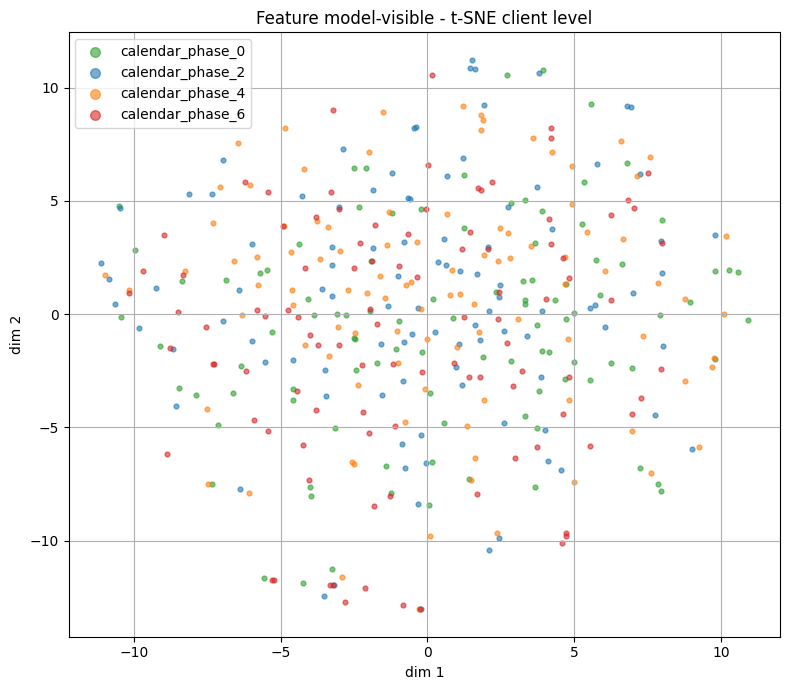

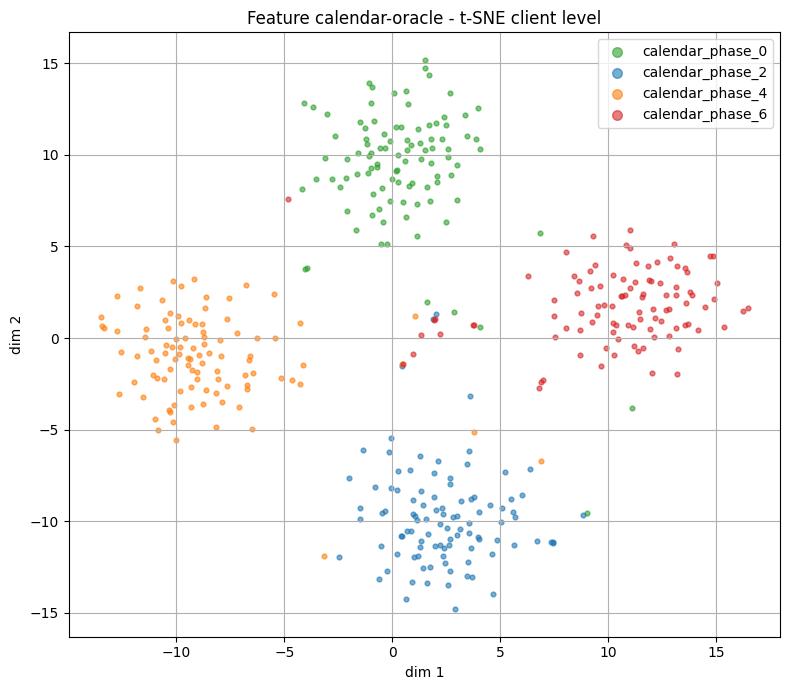

In [24]:
def tsne_projection(feats: pd.DataFrame, title: str):
    # 4000 clienti sono gestibili, ma il campionamento rende il notebook piu reattivo se il dataset cresce.
    sample_n = min(len(feats), 4000)
    sample_idx = feats.sample(sample_n, random_state=0).index
    X = StandardScaler().fit_transform(feats.loc[sample_idx])
    y = labels.loc[sample_idx]

    tsne = TSNE(n_components=2, perplexity=35, init='pca', learning_rate='auto', random_state=0)
    Xt = tsne.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 7))
    for c in clusters:
        mask = y.values == c
        ax.scatter(Xt[mask, 0], Xt[mask, 1], s=12, alpha=0.6, label=c, color=colors_map[c])
    ax.set(title=f'{title} - t-SNE client level', xlabel='dim 1', ylabel='dim 2')
    ax.legend(markerscale=2)
    plt.tight_layout()


tsne_projection(visible_feats, 'Feature model-visible')
tsne_projection(oracle_feats, 'Feature calendar-oracle')


## 7. Conclusioni attese

* `importo`, `merchant` e `cocau` dovrebbero risultare sovrapposti tra i cluster: sono generati da un profilo condiviso.
* `delta_t` dovrebbe essere circa settimanale e uguale tra cluster: il canale temporale usato dal modello non contiene il segnale di classe.
* Il giorno della settimana dovrebbe essere quasi deterministico per cluster: e' il segnale calendariale assoluto, derivato da `timestamp`.
* PCA/t-SNE con feature model-visible dovrebbero mostrare cluster poco separabili; con feature calendar-oracle dovrebbero separarli nettamente. Questo conferma che `simple_calendar` testa proprio cio che il modello corrente non puo modellare senza una feature di tempo assoluto.
